In [7]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("citibike_2022_merged_weather.csv", low_memory=False)

In [17]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df = df[(df["date"] >= "2022-01-01") & (df["date"] <= "2022-12-31")]

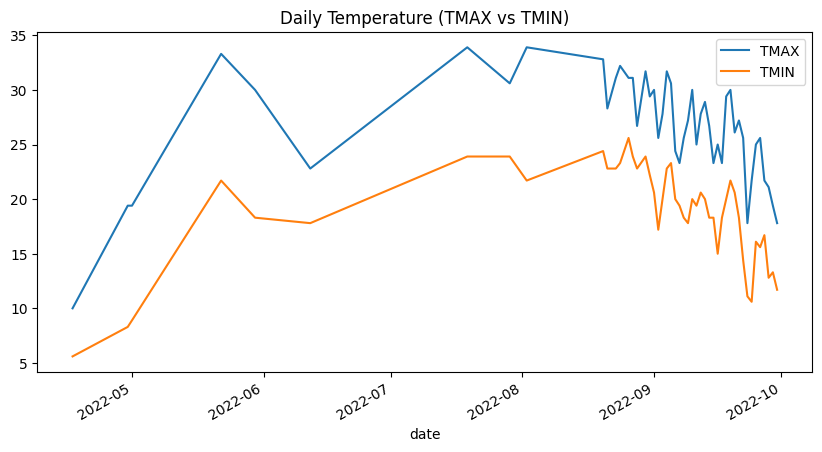

In [18]:
ax = df.groupby("date", as_index=False)[["TMAX","TMIN"]].mean().plot(
    x="date", y=["TMAX","TMIN"], figsize=(10,5)
)
plt.title("Daily Temperature (TMAX vs TMIN)")
plt.show()

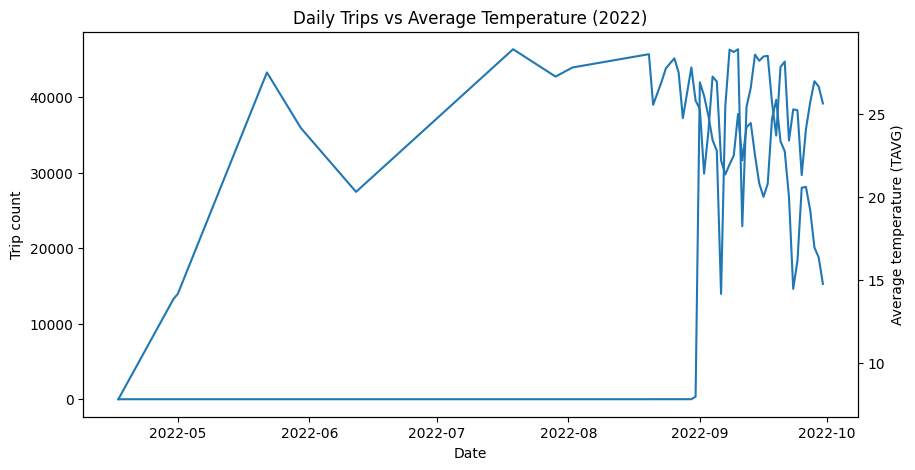

In [15]:

df["date"] = pd.to_datetime(df["date"], errors="coerce")

# 1) Daily trip counts
daily_trips = df.groupby("date", as_index=False).agg(
    trip_count=("ride_id", "size")
)

# 2) Daily weather + average temperature
daily_weather = df.groupby("date", as_index=False).agg(
    TMAX=("TMAX", "mean"),
    TMIN=("TMIN", "mean")
)
daily_weather["TAVG"] = (daily_weather["TMAX"] + daily_weather["TMIN"]) / 2
daily_weather = daily_weather[["date", "TAVG"]]

# 3) Merge trips with weather
daily = pd.merge(daily_trips, daily_weather, on="date", how="inner")

# 4) Keep ONLY 2022
daily = daily[(daily["date"] >= "2022-01-01") & (daily["date"] <= "2022-12-31")]
daily = daily.sort_values("date")

# 5) Dual-axis plot
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(daily["date"], daily["trip_count"])
ax1.set_xlabel("Date")
ax1.set_ylabel("Trip count")

ax2 = ax1.twinx()
ax2.plot(daily["date"], daily["TAVG"])
ax2.set_ylabel("Average temperature (TAVG)")

plt.title("Daily Trips vs Average Temperature (2022)")
plt.show()

In [13]:
print(df.columns)

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'date', 'AWND', 'PRCP', 'TMAX', 'TMIN', 'TAVG'],
      dtype='object')


I used Matplotlib’s object-oriented interface to create the dual-axis plot. I plotted daily trip counts on the primary axis and used twinx() to add a second y-axis for average daily temperature. This allows both variables to share the same time axis while using different scales for trips and temperature.